# X-PIE Modeling — Interactive Notebook

Cross-linking guided protein interaction modeling, run **locally** end-to-end.

This notebook exposes the **complete** `x-pie-modeling.py` workflow:

| Step | What it does | Underlying script |
|---|---|---|
| **0** | Environment / dependency check, input validation | `x-pie-modeling.py` |
| **1** | Cross-link analysis, domain & interface clustering | `scripts/xl_analysis.py` |
| **2** | Distance restraints + XPLOR control script | `scripts/generate-script.py` |
| **3** | PDB/PSF preparation (clean, topology, H rebuild, minimise) | `scripts/pdbpsf-prepare.py` |
| **4** | Conformational sampling (simulated annealing) | `xplor -py refine.py -smp N` |
| **5** | Model selection, energy ranking, RMSD analysis | `scripts/analyze_structures.py` |

**Requirements:** Python 3.8+, Biopython, NumPy, Matplotlib, DSSP (`mkdssp`), and a working
XPLOR-NIH installation. Run the cells top to bottom; every step has its own controls
so you can stop, inspect the intermediate files, edit them, and continue.

**XPLOR paths:** set them once in Step 0 — the values are saved to `x-pie.paths.cfg` and
reloaded automatically, so re-running Step 0 will not erase your edit. Each step also
prints the exact path it is about to use.

## Step 0 — Environment, paths and input validation

The four text fields default to **empty** (with a placeholder showing the expected
pattern). Fill in your real XPLOR toppar directory and executable, then click
**Check environment**. Your entries are persisted to `x-pie.paths.cfg` and reloaded the
next time this cell runs, so they survive a re-run or kernel restart.

In [1]:
import sys, os, shutil, glob, subprocess, importlib.util
!{sys.executable} -m pip install -q biopython numpy matplotlib "ipywidgets>=7.5"

import ipywidgets as widgets
from IPython.display import display, Image, clear_output

os.environ.setdefault('MPLBACKEND', 'Agg')   # headless matplotlib for child processes
print('python :', sys.version.split()[0])
print('mkdssp :', shutil.which('mkdssp') or shutil.which('dssp') or 'NOT FOUND')

python : 3.11.9
mkdssp : /home/pc/.local/dssp-4.6.1/bin/mkdssp


In [2]:
# Point this at the directory holding x-pie-modeling.py (the repository root).
# Leave as '.' if this notebook sits next to the script.
XPIE_DIR = '.'

os.chdir(os.path.abspath(XPIE_DIR))
print('working directory:', os.getcwd())

spec = importlib.util.spec_from_file_location('xpie_modeling', 'x-pie-modeling.py')
xpie = importlib.util.module_from_spec(spec)
spec.loader.exec_module(xpie)
print('loaded x-pie-modeling.py\n')

for f in ['x-pie-modeling.py', 'scripts/xl_analysis.py', 'scripts/generate-script.py',
          'scripts/pdbpsf-prepare.py', 'scripts/analyze_structures.py']:
    print(('OK      ' if os.path.exists(f) else 'MISSING '), f)

working directory: /home/pc/x-pie_notebook
loaded x-pie-modeling.py

OK       x-pie-modeling.py
OK       scripts/xl_analysis.py
OK       scripts/generate-script.py
OK       scripts/pdbpsf-prepare.py
OK       scripts/analyze_structures.py


In [3]:
# --- widget styling (same convention as the Curation notebook) ---
LBL  = {'description_width': '190px'}   # label column, wide enough for full text
ROW  = widgets.Layout(width='560px')    # total control width
WIDE = widgets.Layout(width='auto')     # checkbox labels size themselves
BTN  = widgets.Layout(width='190px')

# ---- paths & input data (persisted so re-running Step 0 keeps your edits) ----
PATHS_FILE = 'x-pie.paths.cfg'           # written by _sync(), reloaded on re-run

def _load_paths():
    d = {}
    if os.path.exists(PATHS_FILE):
        for line in open(PATHS_FILE):
            line = line.strip()
            if line and '=' in line and not line.startswith('#'):
                k, v = line.split('=', 1); d[k.strip()] = v.strip()
    return d

def _save_paths():
    saved = _load_paths()
    saved.update(xplor_home=xh_w.value.strip(), xplor_bin=xb_w.value.strip(),
                 link_file=lk_w.value.strip(),  pdb_dir=pd_w.value.strip())
    with open(PATHS_FILE, 'w') as _f:
        for k in ('xplor_home', 'xplor_bin', 'link_file', 'pdb_dir'):
            _f.write(f'{k} = {saved.get(k, "" )}\n')

_prev = _load_paths()
xh_w = widgets.Text(value=_prev.get('xplor_home', ''),
                    description='XPLOR toppar dir', style=LBL, layout=ROW,
                    placeholder='e.g. /home/gong/data/opt/xplor-nih-3.10/toppar')
xb_w = widgets.Text(value=_prev.get('xplor_bin', ''),
                    description='XPLOR executable', style=LBL, layout=ROW,
                    placeholder='e.g. /home/gong/data/opt/xplor-nih-3.10/bin/xplor')
lk_w = widgets.Text(value=_prev.get('link_file', 'link.dat'),
                    description='cross-link file', style=LBL, layout=ROW)
pd_w = widgets.Text(value=_prev.get('pdb_dir', '.'),
                    description='PDB directory', style=LBL, layout=ROW)
chk  = widgets.Button(description='Check environment', button_style='primary', layout=BTN)
out0 = widgets.Output()

# CFG is shared with every later cell
CFG = {}
def _sync(*_):
    CFG.update(xplor_home=xh_w.value.strip(), xplor_bin=xb_w.value.strip(),
               link_file=lk_w.value.strip(),  pdb_dir=pd_w.value.strip())
    _save_paths()
for w in (xh_w, xb_w, lk_w, pd_w):
    w.observe(_sync, names='value')
_sync()

def check_env(_):
    with out0:
        out0.clear_output(); _sync()
        ok = True
        for mod, pkg in [('Bio.PDB', 'biopython'), ('numpy', 'numpy'), ('matplotlib', 'matplotlib')]:
            try:
                __import__(mod); print(f'  [OK]      {pkg}')
            except ImportError:
                ok = False; print(f'  [MISSING] {pkg}  ->  pip install {pkg}')

        dssp = shutil.which('mkdssp') or shutil.which('dssp')
        print(f'  [OK]      DSSP: {dssp}' if dssp else
              '  [MISSING] DSSP (mkdssp)  ->  conda install -c conda-forge dssp')
        ok = ok and bool(dssp)

        xb = CFG['xplor_bin'] or shutil.which('xplor') or ''
        print(f'  [OK]      XPLOR binary: {xb}' if (xb and os.path.exists(xb)) else
              f'  [MISSING] XPLOR binary not found at: {xb!r}')
        print(f'  [OK]      XPLOR toppar: {CFG["xplor_home"]}' if os.path.isdir(CFG['xplor_home']) else
              f'  [MISSING] XPLOR toppar dir not found: {CFG["xplor_home"]!r}')
        ok = ok and bool(xb) and os.path.exists(xb) and os.path.isdir(CFG['xplor_home'])

        print('\n--- input validation ---')
        valid, missing, prots = xpie.validate_pdb_files(CFG['link_file'], CFG['pdb_dir'])
        if valid:
            print(f'  [OK] all {len(prots)} proteins have a .pdb file: {", ".join(prots)}')
        else:
            ok = False
            print('  [ERROR] missing PDB files:')
            for m in missing:
                print('    -', m)

        print('\n==>', 'Ready to run the pipeline.' if ok else 'Fix the items above before continuing.')

chk.on_click(check_env)
display(widgets.VBox([xh_w, xb_w, lk_w, pd_w, chk]), out0)

Output()

## Step 1 — Cross-link analysis & interface clustering

Partitions each protein into structural domains, identifies disordered linkers (DSSP-based),
and clusters cross-link sites into spatially distinct interaction interfaces.

**Output:** `interface-define/` — `*_domains.txt`, `*_linker.txt`, `*_loop.txt`,
`*_clusters.txt`, `*_schematic.png`.

In [5]:
# --- widget styling (same convention as the Curation notebook) ---
LBL  = {'description_width': '190px'}   # label column, wide enough for full text
ROW  = widgets.Layout(width='560px')    # total control width
WIDE = widgets.Layout(width='auto')     # checkbox labels size themselves
BTN  = widgets.Layout(width='190px')

ll_w = widgets.IntSlider(value=15, min=5, max=40, step=1,
                         description='linker arm length (Å)', style=LBL, layout=ROW)
lf_w = widgets.Checkbox(value=False, indent=False,
                        description='flexible loop handling for intra-domain cross-link sites',
                        style={'description_width': 'initial'}, layout=WIDE)
run1 = widgets.Button(description='Run Step 1', button_style='success', layout=BTN)
out1 = widgets.Output()

def run_step1(_):
    with out1:
        out1.clear_output(); _sync()
        CFG.update(linker_length=int(ll_w.value), use_loop_flexibility=bool(lf_w.value))
        ok = xpie.run_xl_analysis(CFG['linker_length'], CFG['use_loop_flexibility'],
                                  CFG['link_file'], CFG['pdb_dir'])
        # restore the pristine xl_analysis.py (the CLI does the same after Step 1)
        bak = 'scripts/xl_analysis.py.bak'
        if os.path.exists(bak):
            shutil.copyfile(bak, 'scripts/xl_analysis.py'); os.remove(bak)
        print('\nStep 1 success:', ok)
        if ok:
            print(xpie.parse_analysis_results('./interface-define'))

run1.on_click(run_step1)
display(widgets.VBox([ll_w, lf_w, run1]), out1)

Output()

actin_domains.txt
actin:1-375

cofilin_domains.txt
cofilin:1-166

actin_linker.txt
actin:

cofilin_linker.txt
cofilin:

actin_loop.txt
actin:

cofilin_loop.txt
cofilin:

actin_cofilin_clusters.txt
# Protein_A	Site_A	State_A	Protein_B	Site_B	State_B
actin	328	1	cofilin	144	2
actin	326	1	cofilin	144	2
actin	50	1	cofilin	22	1
actin	50	1	cofilin	127	1
actin	61	1	cofilin	127	1

actin_cofilin_schematic.png


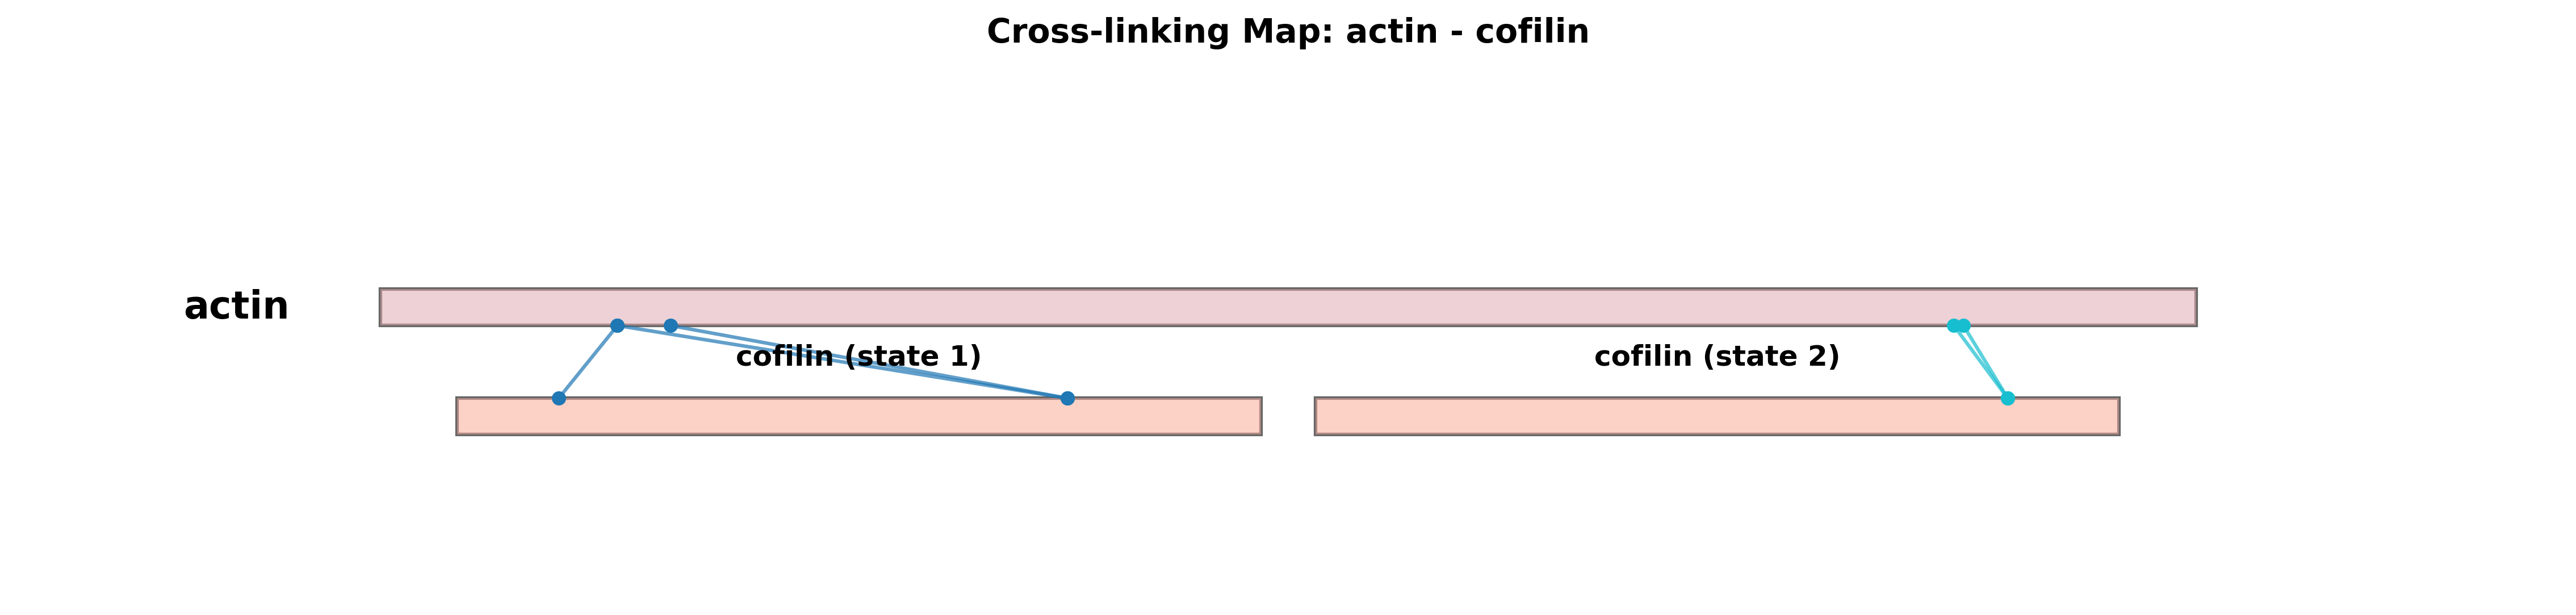

In [6]:
# Inspect every file produced by Step 1 (edit them on disk if you disagree with the
# automatic assignment, then simply continue with Step 2).
d = './interface-define'
if not os.path.isdir(d):
    print('interface-define/ not found — run Step 1 first.')
else:
    for pat in ['*_domains.txt', '*_linker.txt', '*_loop.txt', '*_disordered.txt', '*_clusters.txt']:
        for fp in sorted(glob.glob(os.path.join(d, pat))):
            print('=' * 70); print(os.path.basename(fp)); print('=' * 70)
            print(open(fp).read().strip() or '(empty)'); print()
    for png in sorted(glob.glob(os.path.join(d, '*_schematic.png'))):
        print(os.path.basename(png))
        display(Image(filename=png, width=760))

## Step 2 — Restraint table & XPLOR control script

Converts the interface clusters into distance restraints and writes the simulated-annealing
driver. The resolved XPLOR toppar path is printed below — **verify it is the one you set in
Step 0** before continuing.

**Output:** `input/xlms.tbl` (restraints) and `refine.py` (XPLOR control script).

In [7]:
# --- widget styling (same convention as the Curation notebook) ---
LBL  = {'description_width': '190px'}   # label column, wide enough for full text
ROW  = widgets.Layout(width='560px')    # total control width
WIDE = widgets.Layout(width='auto')     # checkbox labels size themselves
BTN  = widgets.Layout(width='190px')

ns_w = widgets.IntSlider(value=24, min=1, max=200, step=1,
                         description='num structures', style=LBL, layout=ROW)
run2 = widgets.Button(description='Run Step 2', button_style='info', layout=BTN)
out2 = widgets.Output()

def run_step2(_):
    with out2:
        out2.clear_output(); _sync()
        CFG.update(num_structures=int(ns_w.value),
                   linker_length=int(ll_w.value),
                   use_loop_flexibility=bool(lf_w.value))
        print('Resolved paths used for this step:')
        print('   XPLOR toppar :', CFG['xplor_home'] or '(EMPTY — set it in Step 0!)')
        print('   XPLOR binary :', CFG['xplor_bin']  or '(EMPTY — set it in Step 0!)')
        if not CFG['xplor_home'] or not CFG['xplor_bin']:
            print('Step 2 aborted: XPLOR paths are empty.'); return
        ok = xpie.run_generate_script(CFG['linker_length'], CFG['num_structures'],
                                      CFG['xplor_home'], CFG['use_loop_flexibility'])
        print('\nStep 2 success:', ok)
        for fn in ['input/xlms.tbl', 'refine.py', 'input/refine.py']:
            if os.path.exists(fn):
                txt = open(fn).read()
                print(f'\n=== {fn}  ({len(txt.splitlines())} lines, first 40 shown) ===')
                print('\n'.join(txt.splitlines()[:40]))

run2.on_click(run_step2)
display(widgets.VBox([ns_w, run2]), out2)

Output()

## Step 3 — PDB/PSF preparation

Cleans the input PDBs, builds PSF topology, rebuilds hydrogens and runs a short
minimisation. XPLOR is invoked twice per protein, so this typically takes **several minutes
per chain** — output is printed when the step finishes. The resolved XPLOR paths are printed
below.

**Output:** `input/*-prepare.pdb`, `input/*-prepare.psf`.

In [8]:
# --- widget styling (same convention as the Curation notebook) ---
LBL  = {'description_width': '190px'}   # label column, wide enough for full text
ROW  = widgets.Layout(width='560px')    # total control width
WIDE = widgets.Layout(width='auto')     # checkbox labels size themselves
BTN  = widgets.Layout(width='190px')

run3 = widgets.Button(description='Run Step 3', button_style='warning', layout=BTN)
out3 = widgets.Output()

def run_step3(_):
    with out3:
        out3.clear_output(); _sync()
        print('Resolved paths used for this step:')
        print('   XPLOR toppar :', CFG['xplor_home'] or '(EMPTY — set it in Step 0!)')
        print('   XPLOR binary :', CFG['xplor_bin']  or '(EMPTY — set it in Step 0!)')
        if not CFG['xplor_home'] or not CFG['xplor_bin']:
            print('Step 3 aborted: XPLOR paths are empty.'); return
        print('Preparing PDB/PSF — this may take several minutes per protein...')
        ok = xpie.run_pdbpsf_prepare(CFG['xplor_home'], CFG['xplor_bin'], CFG['pdb_dir'])
        print('\nStep 3 success:', ok)
        prepared = sorted(glob.glob('input/*-prepare.pdb')) + sorted(glob.glob('input/*-prepare.psf'))
        print(f'\nprepared files ({len(prepared)}):')
        for f in prepared:
            print('   ', f, f'({os.path.getsize(f)/1024:.0f} KB)')

run3.on_click(run_step3)
display(run3, out3)

Button(button_style='warning', description='Run Step 3', layout=Layout(width='190px'), style=ButtonStyle())

Output()

## Step 4 — Conformational sampling (XPLOR-NIH)

Runs `xplor -py refine.py -smp <cores>` to generate models satisfying the cross-link
restraints under domain rigid-body constraints. The resolved XPLOR binary is printed below.

Tick **launch sampling now** to actually start XPLOR — the button does nothing while it is
unchecked, so you can review `xlms.tbl` / `refine.py` first.

* **background** — detaches the job (`nohup … &`), the kernel stays free, progress goes to
  `xplor_sampling.log`; monitor it with the next cell.
* **foreground** — streams the log into the notebook and **blocks the kernel** until sampling
  finishes.

**Output:** `output/Calc_*.pdb` and `output/Calc_*.pdb.viols`.

In [11]:
# --- widget styling (same convention as the Curation notebook) ---
LBL  = {'description_width': '190px'}   # label column, wide enough for full text
ROW  = widgets.Layout(width='560px')    # total control width
WIDE = widgets.Layout(width='auto')     # checkbox labels size themselves
BTN  = widgets.Layout(width='190px')

nc_w = widgets.IntSlider(value=8, min=1, max=128, step=1,
                         description='CPU cores (-smp)', style=LBL, layout=ROW)
md_w = widgets.RadioButtons(options=['background (nohup, non-blocking)',
                                     'foreground (stream log, blocks kernel)'],
                            value='background (nohup, non-blocking)',
                            description='run mode', style=LBL,
                            layout=widgets.Layout(width='560px'))
go_w = widgets.Checkbox(value=False, indent=False,
                        description='launch XPLOR sampling now',
                        style={'description_width': 'initial'}, layout=WIDE)
run4 = widgets.Button(description='Launch sampling', button_style='danger', layout=BTN)
out4 = widgets.Output()

def run_step4(_):
    with out4:
        out4.clear_output(); _sync()
        print('Resolved paths used for this step:')
        print('   XPLOR binary :', CFG['xplor_bin'] or '(EMPTY — set it in Step 0!)')
        if not CFG['xplor_bin']:
            print('Step 4 aborted: XPLOR binary is empty.'); return
        if not go_w.value:
            print('"launch XPLOR sampling now" is unchecked — nothing was started.')
            print('Manual command:')
            print(f'   {CFG["xplor_bin"]} -py refine.py -smp {int(nc_w.value)}')
            return
        cores, xb = int(nc_w.value), CFG['xplor_bin']
        if not os.path.exists('refine.py'):
            print('refine.py not found — run Step 2 first.'); return
        if md_w.value.startswith('background'):
            xpie.launch_sampling(xb, cores)          # nohup … & , logs to xplor_sampling.log
            print('\nSampling detached. Use the monitor cell below to follow progress.')
        else:
            print(f'$ {xb} -py refine.py -smp {cores}\n' + '-' * 70)
            proc = subprocess.Popen([xb, '-py', 'refine.py', '-smp', str(cores)],
                                    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                                    text=True, bufsize=1)
            with open('xplor_sampling.log', 'w') as lg:
                for line in proc.stdout:
                    lg.write(line); lg.flush()
                    print(line, end='')
            print('-' * 70, '\nexit code:', proc.wait())

run4.on_click(run_step4)
display(widgets.VBox([nc_w, md_w, go_w, run4]), out4)

Output()

In [12]:
# --- widget styling (same convention as the Curation notebook) ---
LBL  = {'description_width': '190px'}   # label column, wide enough for full text
ROW  = widgets.Layout(width='560px')    # total control width
WIDE = widgets.Layout(width='auto')     # checkbox labels size themselves
BTN  = widgets.Layout(width='190px')

# --- sampling monitor: click to refresh -------------------------------------
mon  = widgets.Button(description='Refresh status', button_style='', layout=BTN)
outm = widgets.Output()

def refresh(_):
    with outm:
        outm.clear_output()
        done = sorted(glob.glob('output/Calc_*.pdb'))
        want = CFG.get('num_structures', '?')
        print(f'models written : {len(done)} / {want}')
        viols = glob.glob('output/Calc_*.pdb.viols')
        print(f'violation files: {len(viols)}')
        try:
            running = subprocess.run(['pgrep', '-af', 'refine.py'],
                                     capture_output=True, text=True).stdout.strip()
            print('xplor process  :', running.splitlines()[0] if running else 'not running')
        except FileNotFoundError:
            print('xplor process  : (pgrep unavailable on this OS)')
        if os.path.exists('xplor_sampling.log'):
            tail = open('xplor_sampling.log', errors='replace').read().splitlines()[-25:]
            print('\n--- xplor_sampling.log (last 25 lines) ---')
            print('\n'.join(tail))
        else:
            print('\nxplor_sampling.log not found yet.')

mon.on_click(refresh)
display(mon, outm)

Button(description='Refresh status', layout=Layout(width='190px'), style=ButtonStyle())

Output()

## Step 5 — Model selection & structural analysis

Ranks the sampled models by total energy, discards those with significant atomic clashes or
restraint violations, and reports **ensemble-convergence RMSD**. If a reference structure is
supplied it also reports the **RMSD to that reference** (accuracy, as opposed to convergence).

In [13]:
# --- widget styling (same convention as the Curation notebook) ---
LBL  = {'description_width': '190px'}   # label column, wide enough for full text
ROW  = widgets.Layout(width='560px')    # total control width
WIDE = widgets.Layout(width='auto')     # checkbox labels size themselves
BTN  = widgets.Layout(width='190px')

sd_w = widgets.Text(value='./output', description='structures dir', style=LBL, layout=ROW)
tn_w = widgets.IntSlider(value=5, min=1, max=50, step=1,
                         description='top N structures', style=LBL, layout=ROW)
at_w = widgets.Dropdown(options=['backbone', 'ca', 'heavy'], value='backbone',
                        description='atom type', style=LBL, layout=ROW)
rf_w = widgets.Checkbox(value=False, indent=False, description='compare against a reference structure',
                        style={'description_width': 'initial'}, layout=WIDE)
rp_w = widgets.Text(value='ref.pdb', description='reference PDB', style=LBL, layout=ROW)
rq_w = widgets.Text(value='structure_analysis.txt', description='report file', style=LBL, layout=ROW)
run5 = widgets.Button(description='Run analysis', button_style='success', layout=BTN)
out5 = widgets.Output()

def run_step5(_):
    with out5:
        out5.clear_output()
        if not glob.glob(os.path.join(sd_w.value, 'Calc_*.pdb')):
            print(f'no Calc_*.pdb found in {sd_w.value} — run Step 4 first.'); return
        stdin = f'{sd_w.value}\n{int(tn_w.value)}\n'
        stdin += f'y\n{rp_w.value}\n' if rf_w.value else 'n\n'
        r = subprocess.run([sys.executable, 'scripts/analyze_structures.py',
                            '--atom-type', at_w.value, '-o', rq_w.value],
                           input=stdin, text=True, capture_output=True)
        print(r.stdout)
        if r.returncode != 0:
            print('[stderr]\n', r.stderr)
        if os.path.exists(rq_w.value):
            print('\n' + '=' * 70)
            print(f'report saved to {rq_w.value}')
            print('=' * 70)
            print(open(rq_w.value).read())

run5.on_click(run_step5)
display(widgets.VBox([sd_w, tn_w, at_w, rf_w, rp_w, rq_w, run5]), out5)

Output()

## Appendix — reproduce this run from the command line

The notebook and the CLI share the same code path. The cell below writes an `x-pie.cfg`
carrying your current settings so the whole pipeline can be replayed non-interactively.

In [14]:
_sync()
cfg_txt = f'''[data]
link_file = {CFG.get('link_file', 'link.dat')}
pdb_dir = {CFG.get('pdb_dir', '.')}

[paths]
xplor_home = {CFG.get('xplor_home', '')}
xplor_bin = {CFG.get('xplor_bin', '')}

[parameters]
linker_length = {CFG.get('linker_length', 15)}
num_structures = {CFG.get('num_structures', 24)}
num_cores = 8
use_loop_flexibility = {str(CFG.get('use_loop_flexibility', False)).lower()}

[workflow]
interactive = false
pause_after_analysis = false
pause_after_generate = false
auto_run_sampling = false
edit_timeout_seconds = 0
'''
open('x-pie.cfg', 'w').write(cfg_txt)
print(cfg_txt)
print('=' * 70)
print('Batch run          :  python x-pie-modeling.py --config x-pie.cfg')
print('Interactive run    :  python x-pie-modeling.py')
print('Fresh default cfg  :  python x-pie-modeling.py --generate-config')
print('Post-hoc analysis  :  python scripts/analyze_structures.py --atom-type backbone')
print('\nSet auto_run_sampling = true to let the batch run launch XPLOR automatically.')

[data]
link_file = link.dat
pdb_dir = .

[paths]
xplor_home = /home/pc/x-pie-samping/xplor-nih-3.10/toppar
xplor_bin = /home/pc/x-pie-samping/xplor-nih-3.10/bin/xplor

[parameters]
linker_length = 15
num_structures = 12
num_cores = 8
use_loop_flexibility = false

[workflow]
interactive = false
pause_after_analysis = false
pause_after_generate = false
auto_run_sampling = false
edit_timeout_seconds = 0

Batch run          :  python x-pie-modeling.py --config x-pie.cfg
Interactive run    :  python x-pie-modeling.py
Fresh default cfg  :  python x-pie-modeling.py --generate-config
Post-hoc analysis  :  python scripts/analyze_structures.py --atom-type backbone

Set auto_run_sampling = true to let the batch run launch XPLOR automatically.
